# Lab 2 - Part II: Lọc tuyến tính (Linear Filtering)

In [2]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image = cv2.imread('../data/input/anh.jpg')
image = image[:, :, ::-1]  # BGR -> RGB
print(f'Image loaded: {image.shape}, dtype={image.dtype}')

Image loaded: (914, 735, 3), dtype=uint8


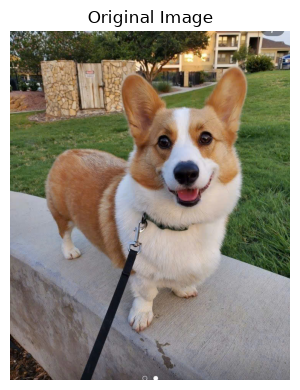

In [3]:
plt.figure(figsize=(5, 4))
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 1. Lọc trung bình (Mean Filter)
- Thay mỗi pixel bằng giá trị **trung bình** của các pixel trong cửa sổ lân cận
- Hiệu quả cao với việc làm mờ ảnh và giảm nhiễu Gauss (Gaussian noise)
- `kernel_size` phải là **số lẻ** (dùng `kernel_size=3`)

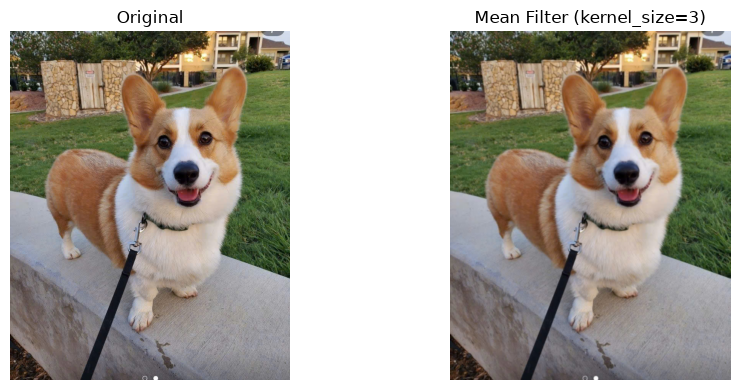

[OK] Saved: output/part2_linear_filters/mean_filtered.jpg


In [4]:
# kernel_size=3 (odd number only)
kernel_size = 3
if kernel_size % 2 == 0:
    raise ValueError('Kernel size must be an odd integer.')
mean = cv2.blur(image, (kernel_size, kernel_size))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(mean)
axes[1].set_title('Mean Filter (kernel_size=3)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

os.makedirs('output/part2_linear_filters', exist_ok=True)
cv2.imwrite('output/part2_linear_filters/mean_filtered.jpg', cv2.cvtColor(mean, cv2.COLOR_RGB2BGR))
print('[OK] Saved: output/part2_linear_filters/mean_filtered.jpg')

---
## 2. Lọc Gaussian (Gaussian Blur)
- Kernel có trọng số phân phối chuẩn (Gaussian distribution): $G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$
- Làm mờ ảnh mượt mà, giảm nhiễu tự nhiên
- `kernel_size=5`, `sigma=0` (OpenCV tự tính sigma từ kernel_size)

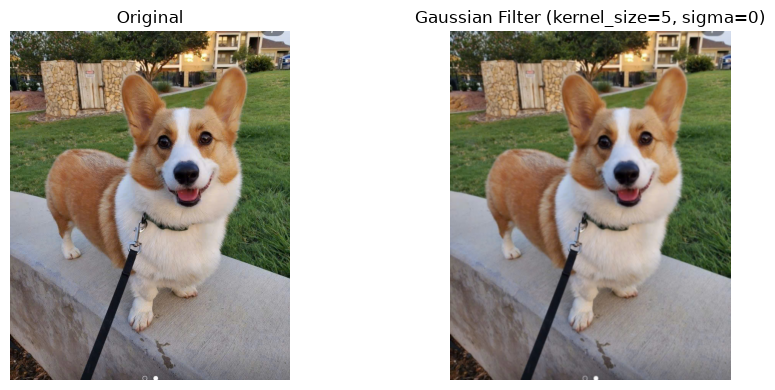

[OK] Saved: output/part2_linear_filters/gaussian_filtered.jpg


In [5]:
# kernel_size=5, sigma=0 (auto from kernel size)
gaussian = cv2.GaussianBlur(image, (5, 5), 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(gaussian)
axes[1].set_title('Gaussian Filter (kernel_size=5, sigma=0)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('output/part2_linear_filters/gaussian_filtered.jpg', cv2.cvtColor(gaussian, cv2.COLOR_RGB2BGR))
print('[OK] Saved: output/part2_linear_filters/gaussian_filtered.jpg')

---
## 3. Lọc làm sắc nét (Sharpen Filter)
- Kernel sharpen tiêu chuẩn 3x3:
  ```
  [[ 0, -1,  0],
   [-1,  6, -1],
   [ 0, -1,  0]]
  ```
- Tăng cường biên và chi tiết, làm ảnh trông rõ nét hơn
- Dùng `cv2.filter2D()` để tích chập ảnh với kernel

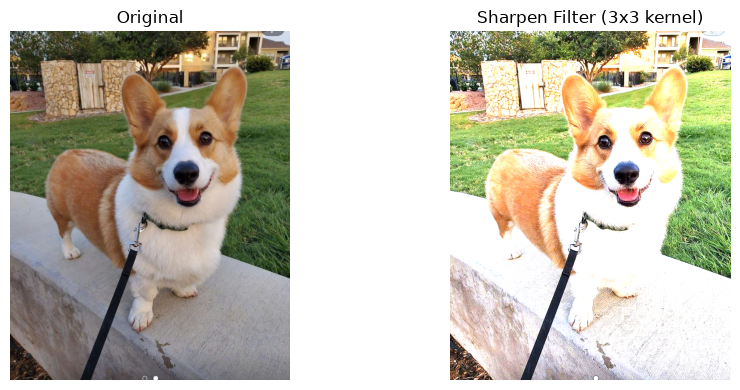

[OK] Saved: output/part2_linear_filters/sharpened.jpg


In [6]:
kernel = np.array([
    [ 0, -1,  0],
    [-1,  6, -1],
    [ 0, -1,  0]
], dtype=np.float32)
sharpened = cv2.filter2D(image, -1, kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(sharpened)
axes[1].set_title('Sharpen Filter (3x3 kernel)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('output/part2_linear_filters/sharpened.jpg', cv2.cvtColor(sharpened, cv2.COLOR_RGB2BGR))
print('[OK] Saved: output/part2_linear_filters/sharpened.jpg')

---
## Tổng kết Part II

| STT | Tác vụ | Công thức / Kernel | Output file |
|-----|--------|-------------------|-------------|
| 1 | Lọc trung bình | `cv2.blur(k=3)` | `mean_filtered.jpg` |
| 2 | Lọc Gaussian | `cv2.GaussianBlur(k=5, σ=0)` | `gaussian_filtered.jpg` |
| 3 | Làm sắc nét | Sharpen 3x3 kernel | `sharpened.jpg` |

**Kết luận:** Lọc tuyến tính dùng phép tích chập giữa ảnh và kernel. Mean filter hiệu quả với nhiễu Gauss; Gaussian làm mờ mượt; Sharpen tăng cường chi tiết.